<a href="https://colab.research.google.com/github/shri-bh/disease_prediction-/blob/main/Disesase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


plt.rcParams['figure.figsize'] = (12, 6)
sns.set(style="whitegrid")

# Paths and loading
dataset_path = '../dataset.csv'
symptom_description_path = '../symptom_Description.csv'
symptom_severity_path = '../Symptom-severity.csv'
symptom_precaution_path = '../symptom_precaution.csv'

dataset_df = pd.read_csv(dataset_path)
symptom_severity_df = pd.read_csv(symptom_severity_path)
symptom_description_df = pd.read_csv(symptom_description_path)
precaution_df = pd.read_csv(symptom_precaution_path)

shapes of data

In [5]:
print(f"Main dataset shape: {dataset_df.shape}")
print(f"Symptom Severity shape: {symptom_severity_df.shape}")
print(f"Symptom Description shape: {symptom_description_df.shape}")
print(f"Symptom Precaution shape: {precaution_df.shape}")

Main dataset shape: (4920, 18)
Symptom Severity shape: (133, 2)
Symptom Description shape: (41, 2)
Symptom Precaution shape: (41, 5)


In [5]:
#print first 5 rows of the dataset
dataset_df.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
#print last 5 rows of the dataset
dataset_df.tail()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
4915,(vertigo) Paroymsal Positional Vertigo,vomiting,headache,nausea,spinning_movements,loss_of_balance,unsteadiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4916,Acne,skin_rash,pus_filled_pimples,blackheads,scurring,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4917,Urinary tract infection,burning_micturition,bladder_discomfort,foul_smell_of urine,continuous_feel_of_urine,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4918,Psoriasis,skin_rash,joint_pain,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4919,Impetigo,skin_rash,high_fever,blister,red_sore_around_nose,yellow_crust_ooze,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#getting some info about the data
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4920 entries, 0 to 4919
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Disease     4920 non-null   object
 1   Symptom_1   4920 non-null   object
 2   Symptom_2   4920 non-null   object
 3   Symptom_3   4920 non-null   object
 4   Symptom_4   4572 non-null   object
 5   Symptom_5   3714 non-null   object
 6   Symptom_6   2934 non-null   object
 7   Symptom_7   2268 non-null   object
 8   Symptom_8   1944 non-null   object
 9   Symptom_9   1692 non-null   object
 10  Symptom_10  1512 non-null   object
 11  Symptom_11  1194 non-null   object
 12  Symptom_12  744 non-null    object
 13  Symptom_13  504 non-null    object
 14  Symptom_14  306 non-null    object
 15  Symptom_15  240 non-null    object
 16  Symptom_16  192 non-null    object
 17  Symptom_17  72 non-null     object
dtypes: object(18)
memory usage: 692.0+ KB


In [10]:
#checking for missing values
dataset_df.isnull().sum()

,0
Disease,0
Symptom_1,0
Symptom_2,0
Symptom_3,0
Symptom_4,348
Symptom_5,1206
Symptom_6,1986
Symptom_7,2652
Symptom_8,2976
Symptom_9,3228


In [9]:
missing_perc = dataset_df.isnull().mean() * 100
missing_perc = missing_perc.drop('Disease')

In [7]:
print("\nPercentage of Missing Values Per Symptom Column:")
print(missing_perc)


Percentage of Missing Values Per Symptom Column:
Symptom_1      0.000000
Symptom_2      0.000000
Symptom_3      0.000000
Symptom_4      7.073171
Symptom_5     24.512195
Symptom_6     40.365854
Symptom_7     53.902439
Symptom_8     60.487805
Symptom_9     65.609756
Symptom_10    69.268293
Symptom_11    75.731707
Symptom_12    84.878049
Symptom_13    89.756098
Symptom_14    93.780488
Symptom_15    95.121951
Symptom_16    96.097561
Symptom_17    98.536585
dtype: float64


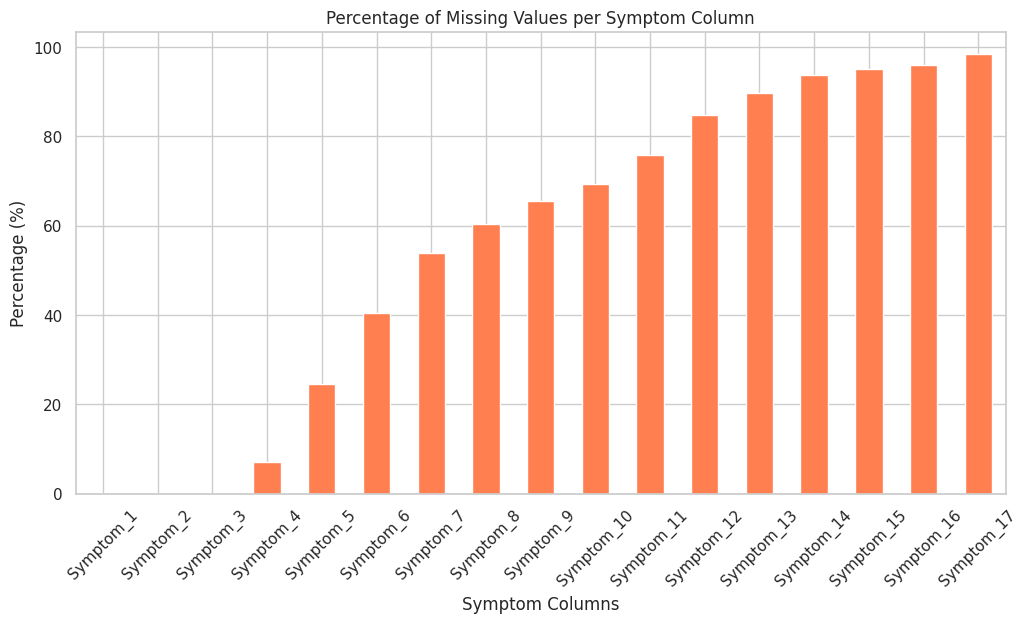

In [8]:
missing_perc.plot(kind='bar', color='coral')
plt.title('Percentage of Missing Values per Symptom Column')
plt.ylabel('Percentage (%)')
plt.xlabel('Symptom Columns')
plt.xticks(rotation=45)
plt.show()


Number of samples per disease (top 10):
Disease
Fungal infection       120
Allergy                120
GERD                   120
Chronic cholestasis    120
Drug Reaction          120
Peptic ulcer diseae    120
AIDS                   120
Diabetes               120
Gastroenteritis        120
Bronchial Asthma       120
Name: count, dtype: int64


<ipython-input-9-7369cae94213>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=disease_counts.index[:10], x=disease_counts.values[:10], palette='viridis')


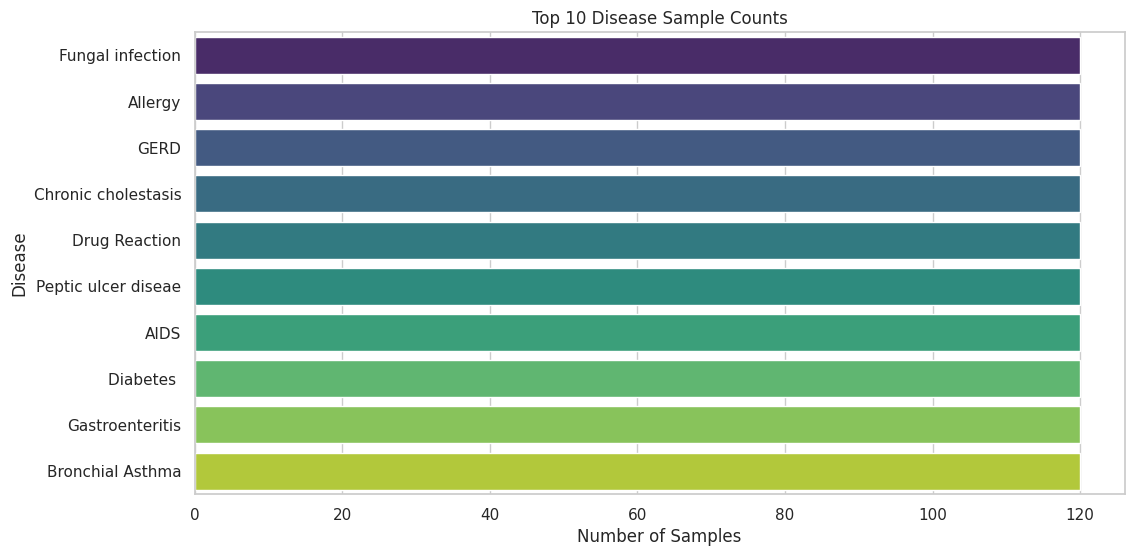

In [9]:
disease_counts = dataset_df['Disease'].value_counts()

print("\nNumber of samples per disease (top 10):")
print(disease_counts.head(10))

sns.barplot(y=disease_counts.index[:10], x=disease_counts.values[:10], palette='viridis')
plt.title('Top 10 Disease Sample Counts')
plt.xlabel('Number of Samples')
plt.ylabel('Disease')
plt.show()

In [10]:
symptom_cols = [col for col in dataset_df.columns if col.startswith('Symptom_')]
unique_counts = dataset_df[symptom_cols].nunique()

print("\nNumber of unique symptom labels per symptom column:")
print(unique_counts)



Number of unique symptom labels per symptom column:
Symptom_1     34
Symptom_2     48
Symptom_3     54
Symptom_4     50
Symptom_5     38
Symptom_6     32
Symptom_7     26
Symptom_8     21
Symptom_9     22
Symptom_10    21
Symptom_11    18
Symptom_12    11
Symptom_13     8
Symptom_14     4
Symptom_15     3
Symptom_16     3
Symptom_17     1
dtype: int64


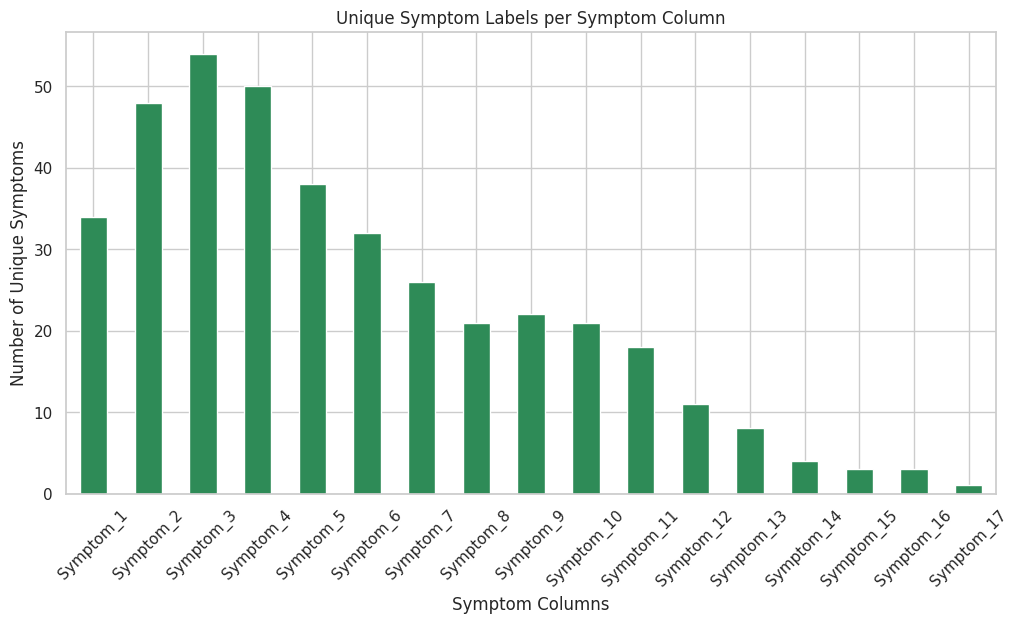

In [11]:
unique_counts.plot(kind='bar', color='seagreen')
plt.title('Unique Symptom Labels per Symptom Column')
plt.ylabel('Number of Unique Symptoms')
plt.xlabel('Symptom Columns')
plt.xticks(rotation=45)
plt.show()

In [12]:
print("\nSymptom Severity Sample:")
print(symptom_severity_df.head())


Symptom Severity Sample:
                Symptom  weight
0               itching       1
1             skin_rash       3
2  nodal_skin_eruptions       4
3   continuous_sneezing       4
4             shivering       5


In [13]:
print(symptom_severity_df['weight'].value_counts().sort_index())

weight
1     1
2    15
3    21
4    39
5    35
6    17
7     5
Name: count, dtype: int64


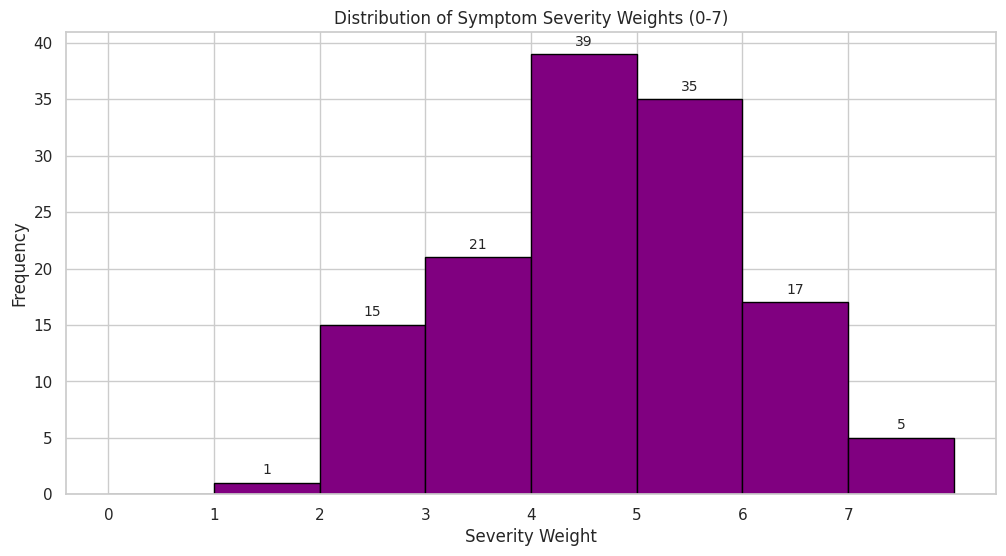

In [14]:
import matplotlib.pyplot as plt

weights = symptom_severity_df['weight']


bins = range(0, 9)
counts, bins_, patches = plt.hist(weights, bins=bins, edgecolor='black', color='purple')

plt.title('Distribution of Symptom Severity Weights (0-7)')
plt.xlabel('Severity Weight')
plt.ylabel('Frequency')
plt.xticks(range(0, 8))  # Show ticks for each integer severity weight

# Add counts on top of bars
for count, patch in zip(counts, patches):
    if count > 0:
        plt.text(patch.get_x() + patch.get_width() / 2, count + 0.5,  # position above the bar
                 int(count), ha='center', va='bottom', fontsize=10)

plt.show()

# New Section

In [11]:
#checking the distribution of target variable
dataset_df['Disease'].value_counts()

,count
Disease,
Fungal infection,120
Hepatitis C,120
Hepatitis E,120
Alcoholic hepatitis,120
Tuberculosis,120
Common Cold,120
Pneumonia,120
Dimorphic hemmorhoids(piles),120
Heart attack,120
